In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-11-17 13:23:47.773973


11/10/25: Removed cell area threshold

# Fine-tuned filtering

* Transcript count: just remove cells in top quarter of percent for each sample
* Area: No threshold
* Doublet scores: remove cells scored > 99th percentile using scrublet

In [2]:
import os
from pathlib import Path
import scanpy as sc
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import anndata as ad
import session_info

In [3]:
warnings.filterwarnings("ignore", category=FutureWarning)

In [4]:
base_dir = Path('/home/workspace/projects/drg')

input_dirs = {
    "whole": base_dir / "data/h5ad/export_01/04a_scrublet/whole",
    "nuclear": base_dir / "data/h5ad/export_01/04b_scrublet/nuclear_only",
}

output_dir = base_dir / "data/h5ad/export_01/04_filtered"
fig_dir = base_dir / "figures/qc"

output_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

In [5]:
mapping = {
    'TMA00303': 1,
    'TMA00304': 1,
    'TMA00305': 2,
    'TMA00306': 2
}

## Filter

In [6]:
whole_files = sorted(
    f for f in os.listdir(input_dirs["whole"])
    if f.endswith(".h5ad") and f.startswith("TMA")
)
nuclear_files = sorted(
    f for f in os.listdir(input_dirs["nuclear"])
    if f.endswith(".h5ad") and f.startswith("TMA")
)

whole_adata_list = [
    ad.read_h5ad(input_dirs["whole"] / f).copy()
    for f in whole_files
]
nuclear_adata_list = [
    ad.read_h5ad(input_dirs["nuclear"] / f).copy()
    for f in nuclear_files
]

In [7]:
print(whole_adata_list)
print('-'*40)
print(nuclear_adata_list)

[AnnData object with n_obs × n_vars = 11408 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'nuclear_fraction', 'doublet_scores', 'predicted_doublets'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'spatial'
    layers: 'nuclear', 'raw', AnnData object with n_obs × n_vars = 21501 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_cou

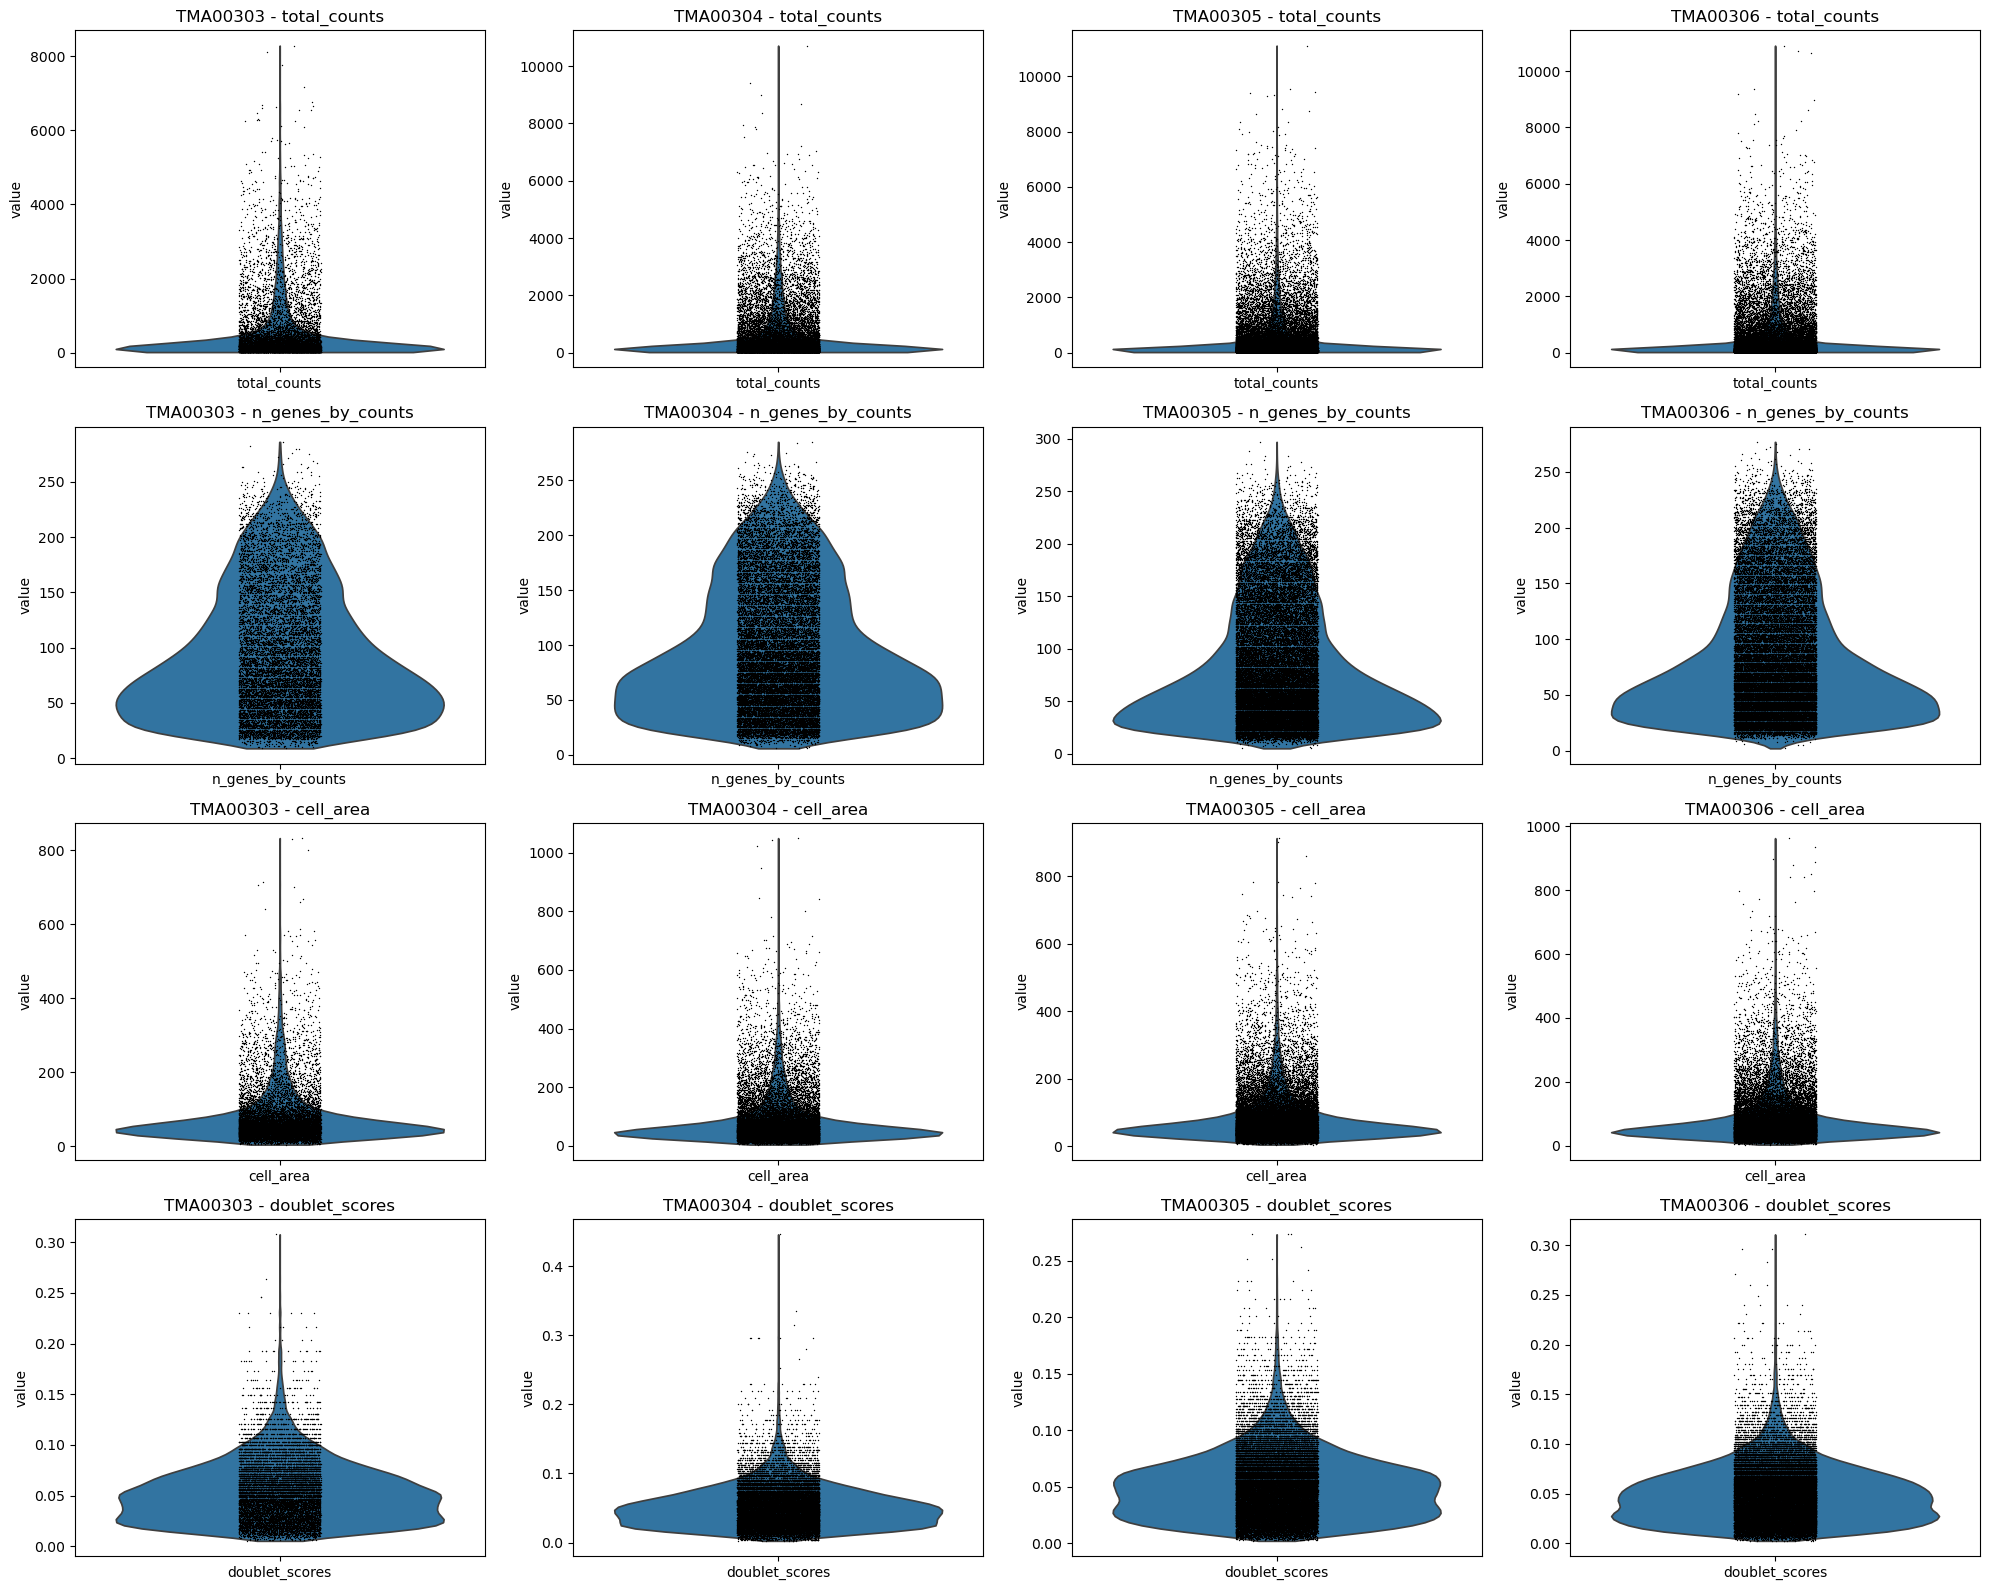

In [8]:
features = ['total_counts', 'n_genes_by_counts', 'cell_area', 'doublet_scores']
fig, axes = plt.subplots(len(features), len(whole_adata_list), figsize=(len(whole_adata_list) * 5, len(features) * 4))

for col_idx, adata in enumerate(whole_adata_list):
    for row_idx, feature in enumerate(features):
        sc.pl.violin(adata, feature, ax=axes[row_idx, col_idx], show=False)
        axes[row_idx, col_idx].set_title(f"{adata.obs['output_id'].unique()[0]} - {feature}")

plt.tight_layout()
plt.show()

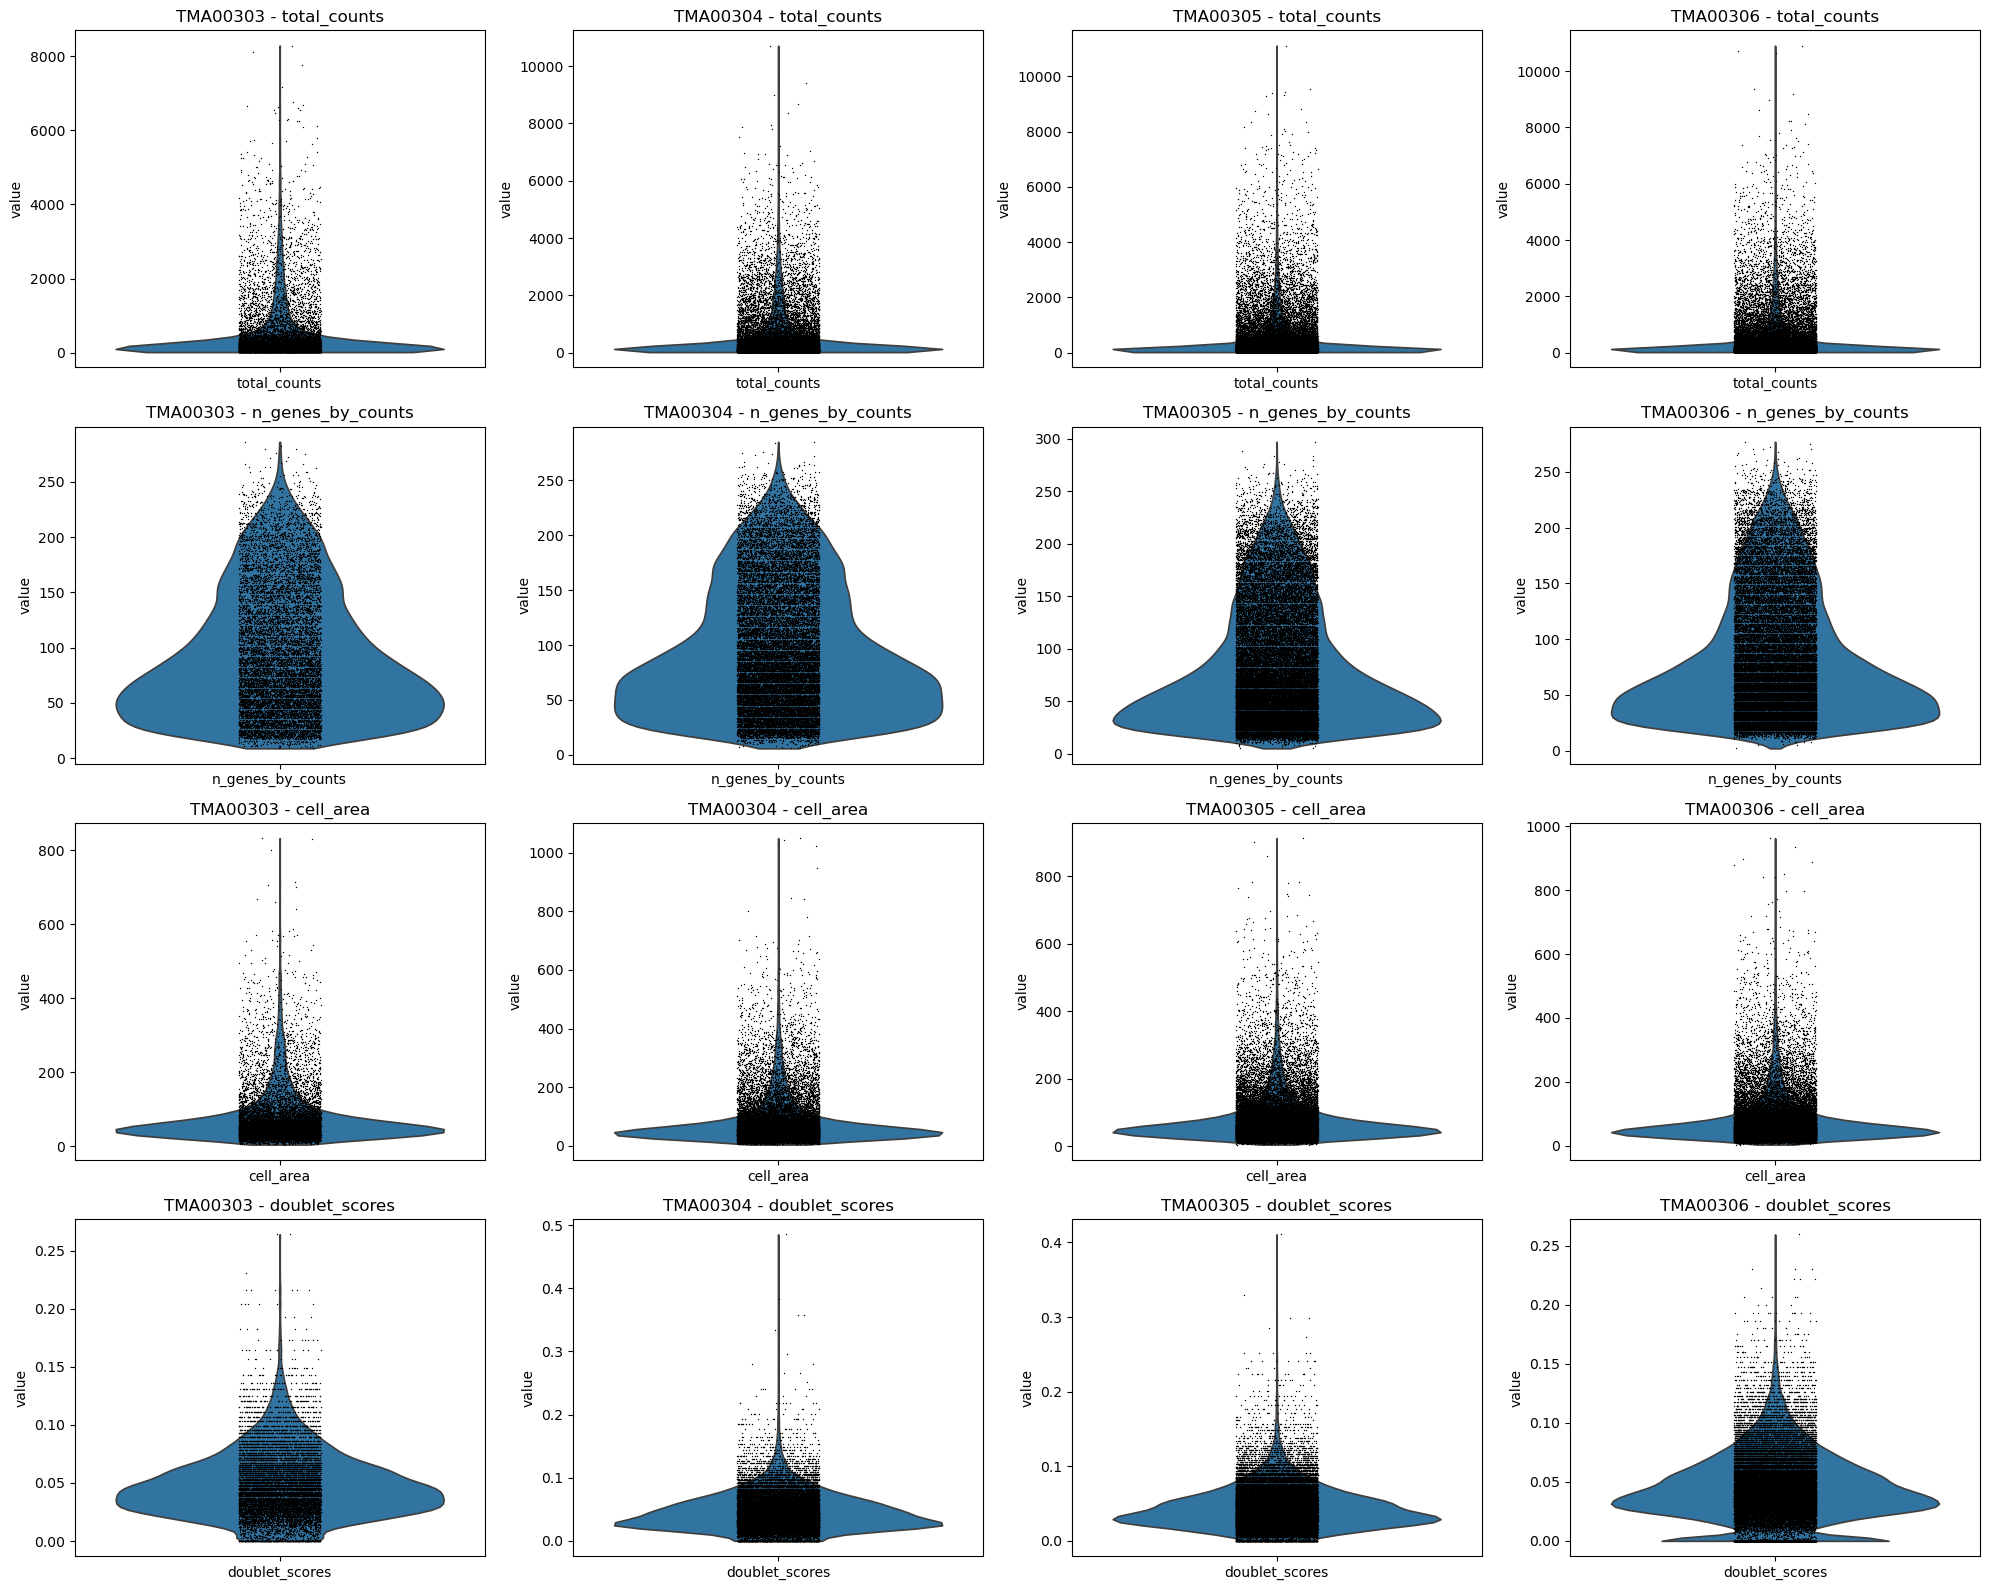

In [9]:
fig, axes = plt.subplots(len(features), len(nuclear_adata_list), figsize=(len(nuclear_adata_list) * 5, len(features) * 4))

for col_idx, adata in enumerate(nuclear_adata_list):
    for row_idx, feature in enumerate(features):
        sc.pl.violin(adata, feature, ax=axes[row_idx, col_idx], show=False)
        axes[row_idx, col_idx].set_title(f"{adata.obs['output_id'].unique()[0]} - {feature}")

plt.tight_layout()
plt.show()

## Filters

In [10]:
# transcript count -- just remove extreme outliers (top quarter of a percent)
for adata in whole_adata_list:
    sample_id = adata.obs["output_id"].iloc[0] if "output_id" in adata.obs else "unknown"
    print(f"\nWhole-cell: {sample_id} | before filter: {adata.shape}")
    total_counts_ceiling = adata.obs["total_counts"].quantile(0.9975)
    adata._inplace_subset_obs(adata.obs["total_counts"] < total_counts_ceiling)
    print(f"Whole-cell: {sample_id} | after filter: {adata.shape}")

for adata in nuclear_adata_list:
    sample_id = adata.obs["output_id"].iloc[0] if "output_id" in adata.obs else "unknown"
    print(f"\nNuclear: {sample_id} | before filter: {adata.shape}")
    total_counts_ceiling = adata.obs["total_counts"].quantile(0.9975)
    adata._inplace_subset_obs(adata.obs["total_counts"] < total_counts_ceiling)
    print(f"Nuclear: {sample_id} | after filter: {adata.shape}")


Whole-cell: TMA00303 | before filter: (11408, 480)
Whole-cell: TMA00303 | after filter: (11379, 480)

Whole-cell: TMA00304 | before filter: (21501, 480)
Whole-cell: TMA00304 | after filter: (21447, 480)

Whole-cell: TMA00305 | before filter: (33118, 480)
Whole-cell: TMA00305 | after filter: (33035, 480)

Whole-cell: TMA00306 | before filter: (32284, 480)
Whole-cell: TMA00306 | after filter: (32203, 480)

Nuclear: TMA00303 | before filter: (11408, 480)
Nuclear: TMA00303 | after filter: (11379, 480)

Nuclear: TMA00304 | before filter: (21501, 480)
Nuclear: TMA00304 | after filter: (21447, 480)

Nuclear: TMA00305 | before filter: (33118, 480)
Nuclear: TMA00305 | after filter: (33035, 480)

Nuclear: TMA00306 | before filter: (32284, 480)
Nuclear: TMA00306 | after filter: (32203, 480)


In [11]:
# Doublet scores -- remove cells scoring in top 1% for doublets
for adata in whole_adata_list:
    sample_id = adata.obs["output_id"].iloc[0] if "output_id" in adata.obs else "unknown"
    print(f"\nWhole-cell: {sample_id} | before filter: {adata.shape}")
    doublet_threshold = adata.obs["doublet_scores"].quantile(0.99)
    adata._inplace_subset_obs(adata.obs["doublet_scores"] < doublet_threshold)
    print(f"Whole-cell: {sample_id} | after filter: {adata.shape}")

for adata in nuclear_adata_list:
    sample_id = adata.obs["output_id"].iloc[0] if "output_id" in adata.obs else "unknown"
    print(f"\nNuclear: {sample_id} | before filter: {adata.shape}")
    doublet_threshold = adata.obs["doublet_scores"].quantile(0.99)
    adata._inplace_subset_obs(adata.obs["doublet_scores"] < doublet_threshold)
    print(f"Nuclear: {sample_id} | after filter: {adata.shape}")


Whole-cell: TMA00303 | before filter: (11379, 480)
Whole-cell: TMA00303 | after filter: (11261, 480)

Whole-cell: TMA00304 | before filter: (21447, 480)
Whole-cell: TMA00304 | after filter: (21232, 480)

Whole-cell: TMA00305 | before filter: (33035, 480)
Whole-cell: TMA00305 | after filter: (32681, 480)

Whole-cell: TMA00306 | before filter: (32203, 480)
Whole-cell: TMA00306 | after filter: (31853, 480)

Nuclear: TMA00303 | before filter: (11379, 480)
Nuclear: TMA00303 | after filter: (11255, 480)

Nuclear: TMA00304 | before filter: (21447, 480)
Nuclear: TMA00304 | after filter: (21206, 480)

Nuclear: TMA00305 | before filter: (33035, 480)
Nuclear: TMA00305 | after filter: (32687, 480)

Nuclear: TMA00306 | before filter: (32203, 480)
Nuclear: TMA00306 | after filter: (31869, 480)



[Violin Plots] Whole-cell datasets


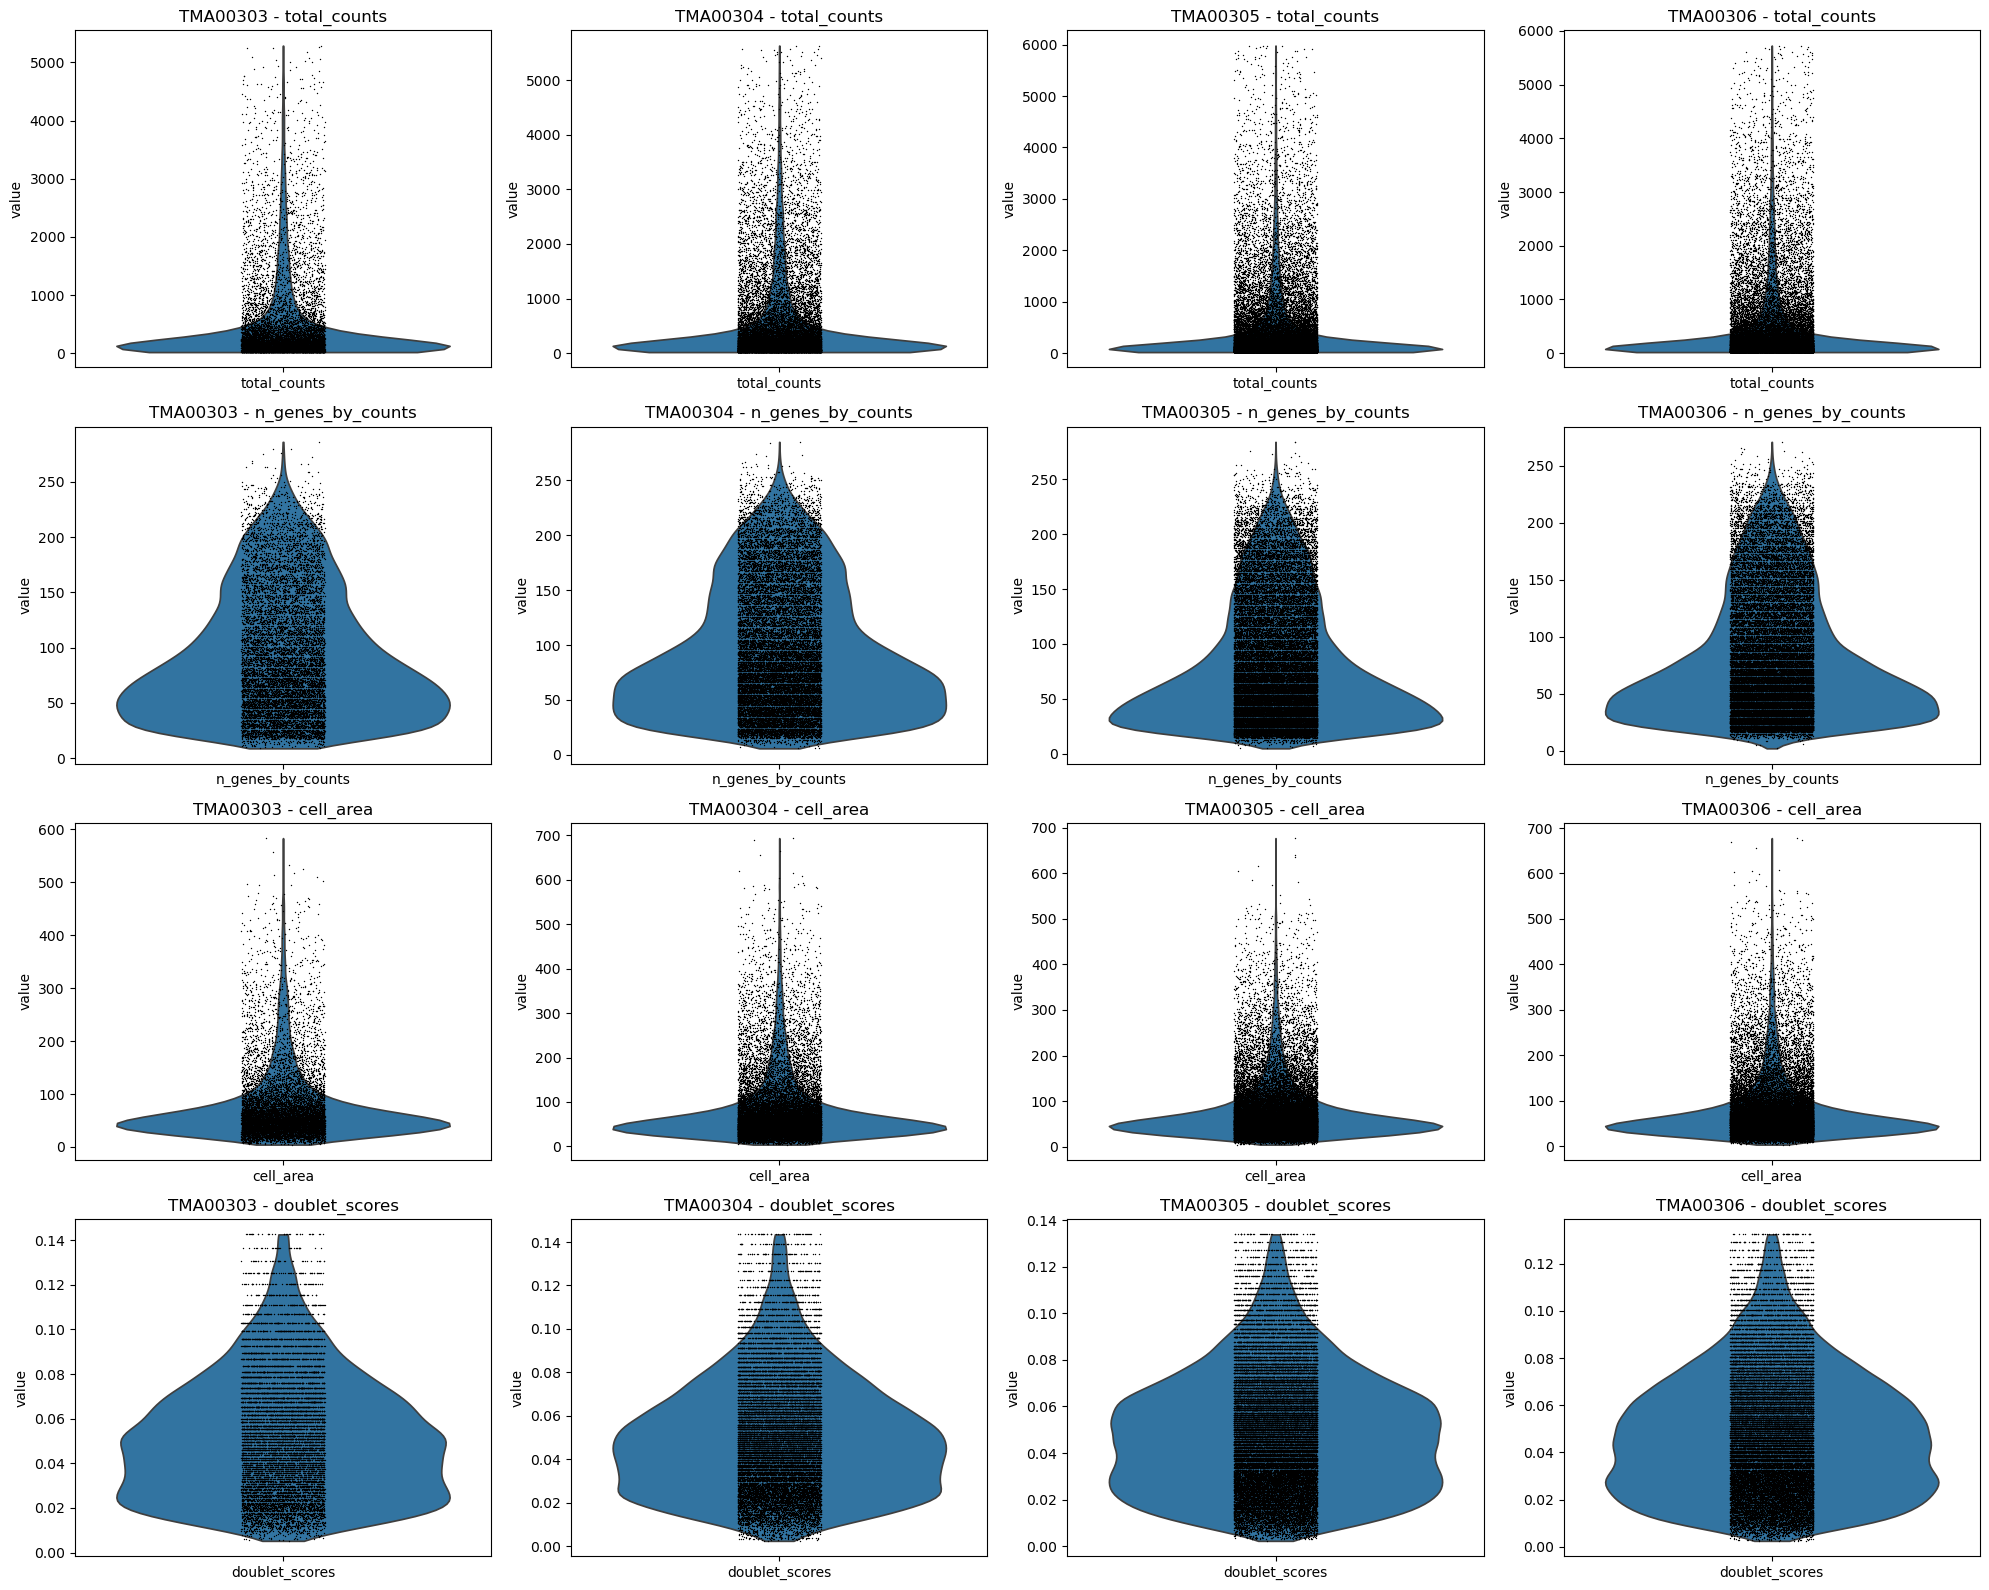


[Violin Plots] Nuclear-only datasets


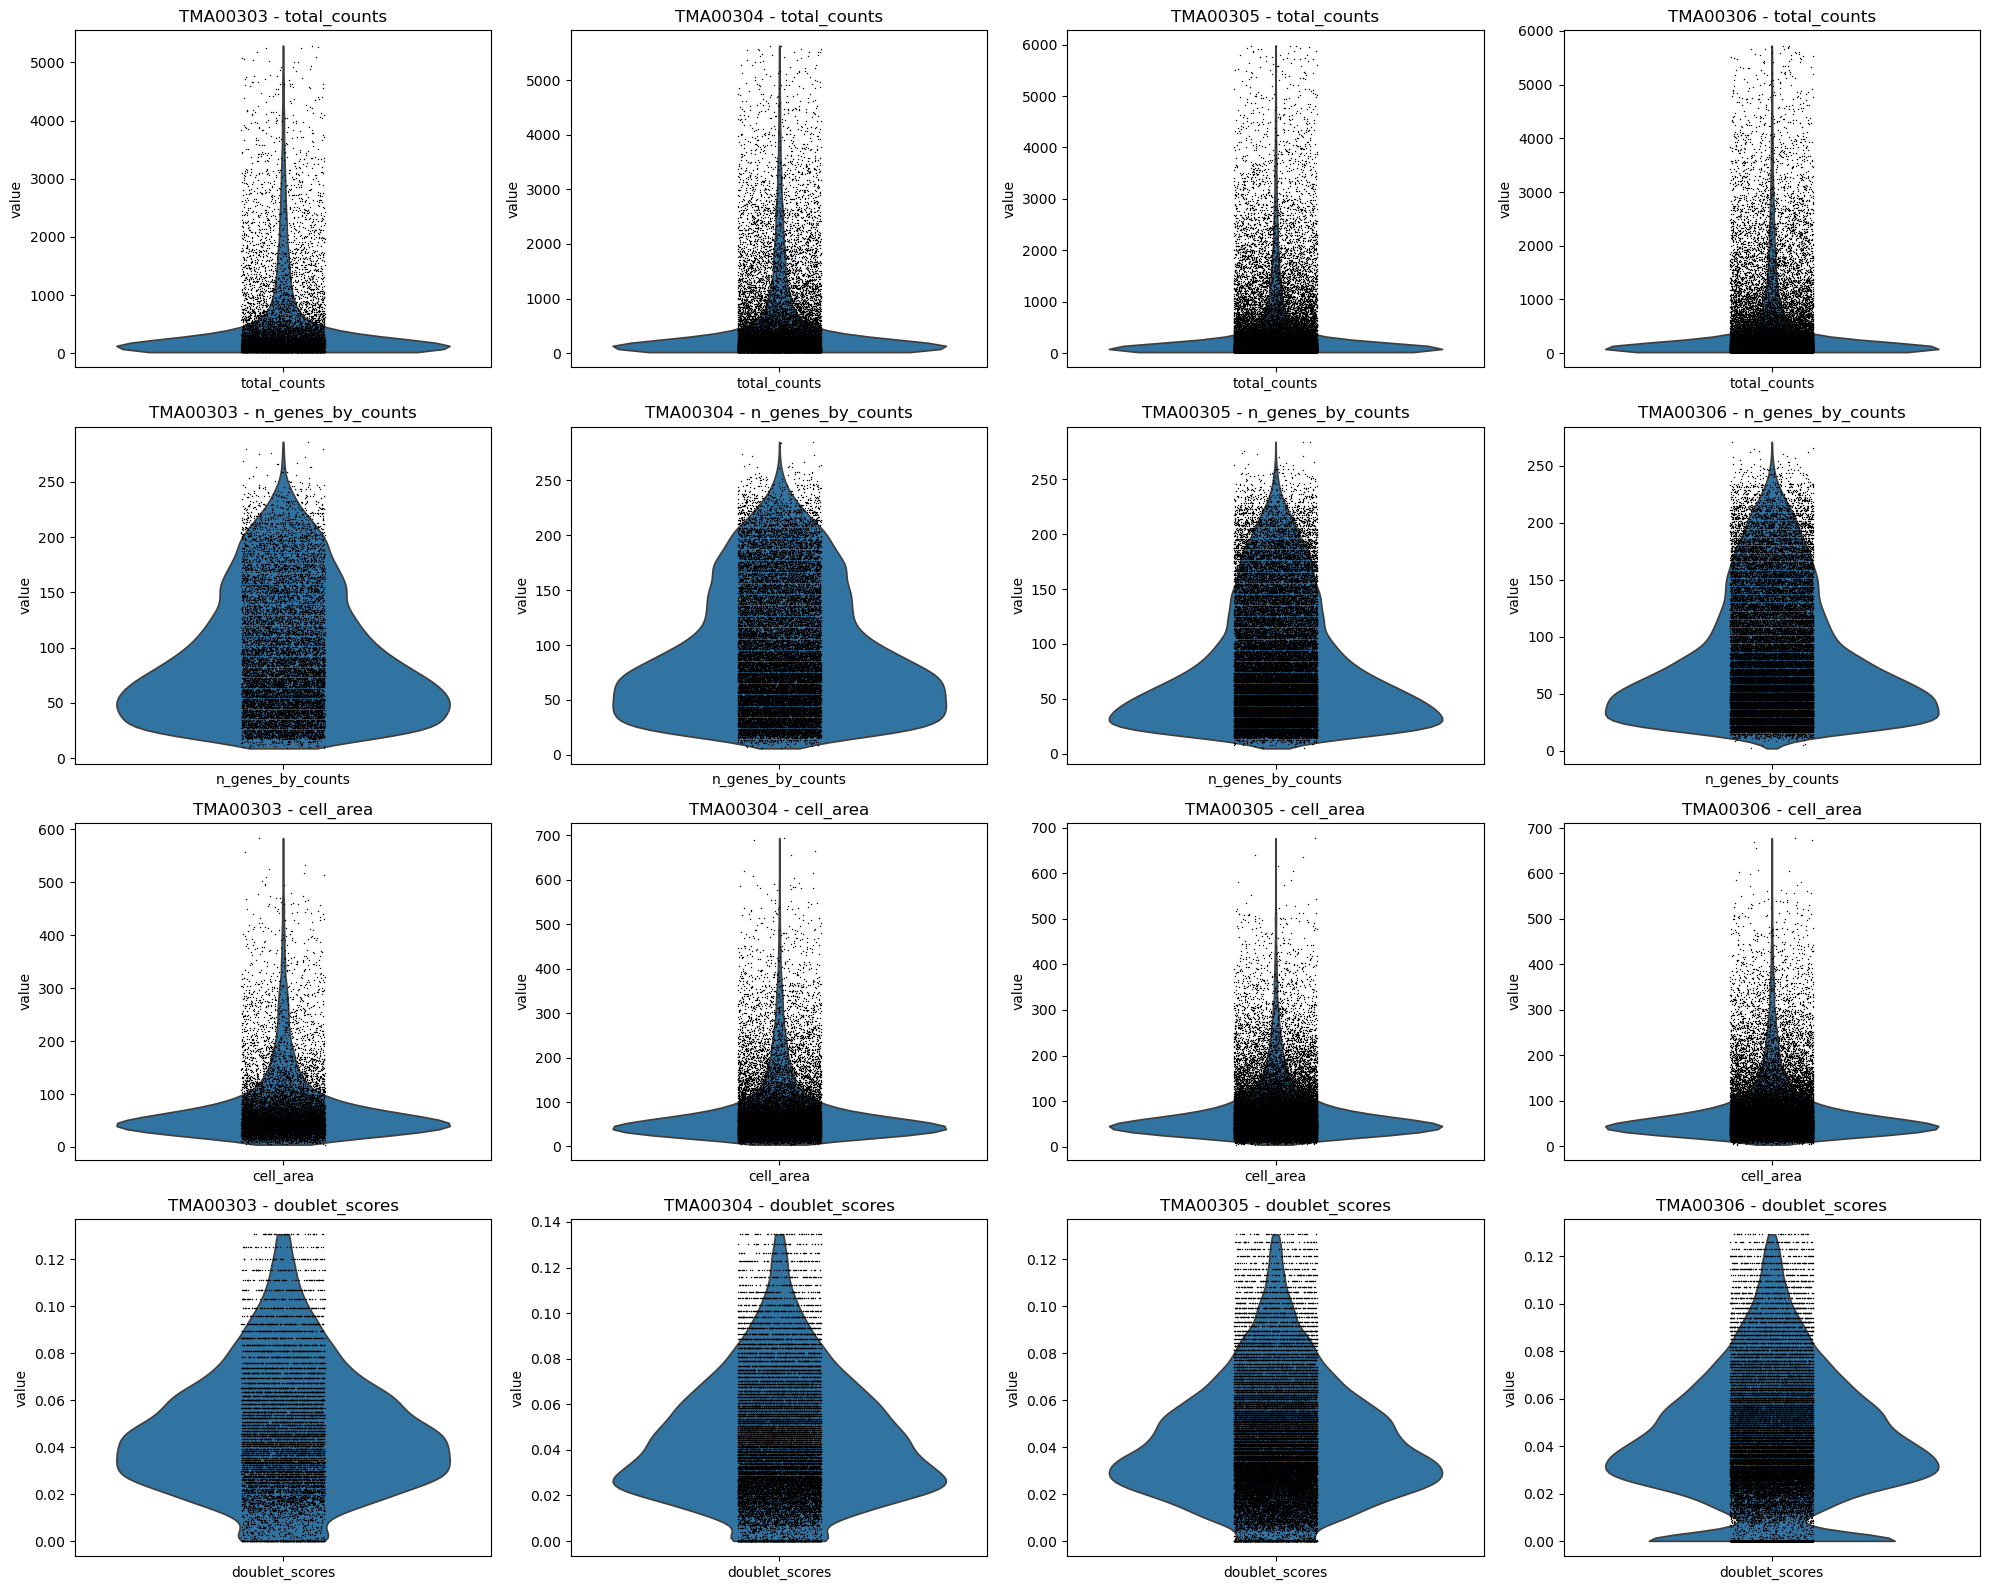

In [12]:
print("\n[Violin Plots] Whole-cell datasets")
fig, axes = plt.subplots(len(features), len(whole_adata_list), figsize=(len(whole_adata_list) * 5, len(features) * 4))
for col_idx, adata in enumerate(whole_adata_list):
    for row_idx, feature in enumerate(features):
        sc.pl.violin(adata, feature, ax=axes[row_idx, col_idx], show=False)
        axes[row_idx, col_idx].set_title(f"{adata.obs['output_id'].unique()[0]} - {feature}")
plt.tight_layout()
plt.show()


print("\n[Violin Plots] Nuclear-only datasets")
fig, axes = plt.subplots(len(features), len(nuclear_adata_list), figsize=(len(nuclear_adata_list) * 5, len(features) * 4))
for col_idx, adata in enumerate(nuclear_adata_list):
    for row_idx, feature in enumerate(features):
        sc.pl.violin(adata, feature, ax=axes[row_idx, col_idx], show=False)
        axes[row_idx, col_idx].set_title(f"{adata.obs['output_id'].unique()[0]} - {feature}")
plt.tight_layout()
plt.show()

## Visualize qc metrics


[Spatial QC] Whole-cell datasets
TMA00303


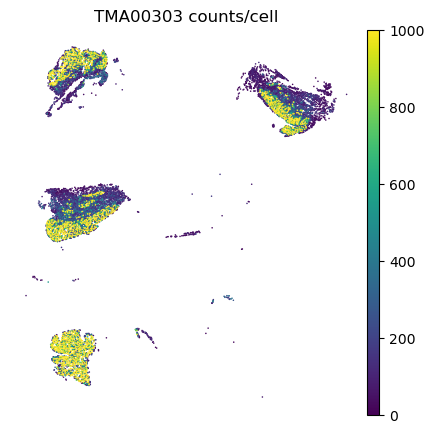

TMA00304


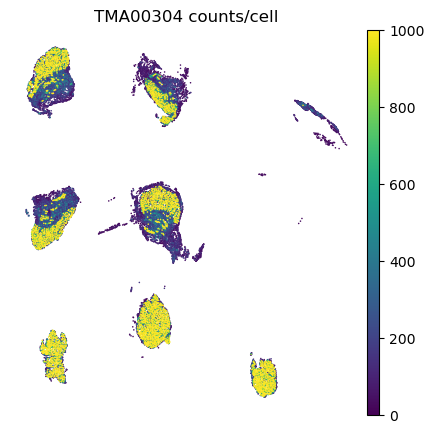

TMA00305


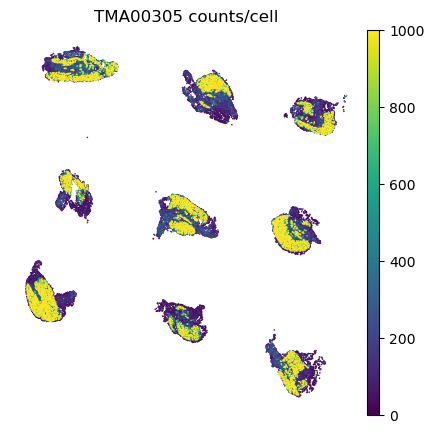

TMA00306


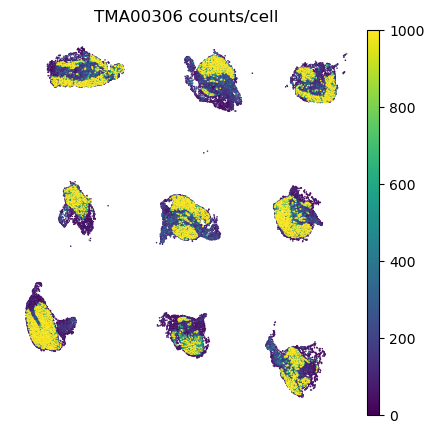

In [13]:
# Whole-cell spatial QC plots for total_counts
print("\n[Spatial QC] Whole-cell datasets")
for adata in whole_adata_list:
    sample_id = adata.obs['output_id'].iloc[0]
    print(sample_id)

    fig, ax = plt.subplots(figsize=(5, 5))
    sc.pl.embedding(adata, basis='spatial', color='total_counts',
                    title=f'{sample_id} counts/cell',
                    vmin=0, vmax=1000, size=5, ax=ax, frameon=False)

    fig.savefig(os.path.join(fig_dir, f'{sample_id}_spatial_QC.png'))
    plt.close(fig)

In [14]:
# Nuclear-only spatial QC plots for total_counts
#print("\n[Spatial QC] Nuclear-only datasets")
#for adata in nuclear_adata_list:
#    sample_id = adata.obs['output_id'].iloc[0]
#    print(sample_id)

#    fig, ax = plt.subplots(figsize=(5, 5))
#    sc.pl.embedding(adata, basis='spatial', color='total_counts',
#                    title=f'{sample_id} counts/cell',
#                    vmin=0, vmax=1000, size=5, ax=ax, frameon=False)

#    fig.savefig(os.path.join(fig_dir, f'{sample_id}_spatial_QC.png'))
#    plt.close(fig)

In [15]:
#for adata in adata_list:
#    sample_id = adata.obs['output_id'].iloc[0]
#    print(sample_id)

#    fig, ax = plt.subplots(figsize=(5, 5))
#    sc.pl.embedding(adata, basis='spatial', color='doublet_scores', title=sample_id + ' doublet scores',
#                    vmin=0, size=5, ax=ax, frameon = False)  # Pass ax explicitly

#    fig.savefig(os.path.join(fig_dir, sample_id + '_doublets_spatial_QC.png'))
#    plt.close(fig)

In [16]:
#for adata in adata_list:
#    sample_id = adata.obs['output_id'].iloc[0]
#    print(sample_id)

#    fig, ax = plt.subplots(figsize=(5, 5))
#    sc.pl.embedding(adata, basis='spatial', color='cell_area', title=sample_id + ' cell area',
#                    vmin=0, size=5, ax=ax, frameon = False)  # Pass ax explicitly

#    fig.savefig(os.path.join(fig_dir, sample_id + '_cell_area_spatial_QC.png'))
#    plt.close(fig)

## Concatenate

In [17]:
# Concatenate whole-cell datasets
adata_whole = ad.concat(
    whole_adata_list,
    join="outer",
    label='batch',
    index_unique="-"
)
print("Concatenated whole-cell AnnData:")
print(adata_whole)

# Concatenate nuclear-only datasets
adata_nuclear = ad.concat(
    nuclear_adata_list,
    join="outer",
    label='batch',
    index_unique="-"
)
print("Concatenated nuclear-only AnnData:")
print(adata_nuclear)

Concatenated whole-cell AnnData:
AnnData object with n_obs × n_vars = 97027 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'nuclear_fraction', 'doublet_scores', 'predicted_doublets', 'batch'
    obsm: 'spatial'
    layers: 'nuclear', 'raw'
Concatenated nuclear-only AnnData:
AnnData object with n_obs × n_vars = 97017 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts',

# Complete metadata

Add slide information

In [18]:
# Map slide IDs to whole-cell dataset
adata_whole.obs['slide'] = adata_whole.obs['output_id'].map(mapping)
print("Whole-cell data slide breakdown:")
print(adata_whole.obs['slide'].value_counts())

print("\n" + "-" * 50 + "\n")

# Map slide IDs to nuclear-only dataset
adata_nuclear.obs['slide'] = adata_nuclear.obs['output_id'].map(mapping)
print("Nuclear-only data slide breakdown:")
print(adata_nuclear.obs['slide'].value_counts())

Whole-cell data slide breakdown:
slide
2    64534
1    32493
Name: count, dtype: int64

--------------------------------------------------

Nuclear-only data slide breakdown:
slide
2    64556
1    32461
Name: count, dtype: int64


## Normalize

In [19]:
# Normalize and log-transform whole-cell data
adata_whole.layers["counts"] = adata_whole.X.copy()
sc.pp.normalize_total(adata_whole, target_sum=1e6)
adata_whole.layers["normalized_1e6"] = adata_whole.X.copy()

sc.pp.log1p(adata_whole)
adata_whole.raw = adata_whole.copy()
adata_whole.layers["log1p"] = adata_whole.X.copy()

In [20]:
# Normalize and log-transform nuclear-only data
adata_nuclear.layers["counts"] = adata_nuclear.X.copy()
sc.pp.normalize_total(adata_nuclear, target_sum=1e6)
adata_nuclear.layers["normalized_1e6"] = adata_nuclear.X.copy()

sc.pp.log1p(adata_nuclear)
adata_nuclear.raw = adata_nuclear.copy()
adata_nuclear.layers["log1p"] = adata_nuclear.X.copy()

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


## Export

In [21]:
# Whole-cell
filename = os.path.join(output_dir, 'adata-filtered_whole.h5ad')
os.makedirs(os.path.dirname(filename), exist_ok=True)
adata_whole.write_h5ad(filename, compression='gzip')
print(f'Filtered, concatenated whole-cell AnnData saved to: {filename}')

# Nuclear
filename = os.path.join(output_dir, 'adata-filtered_nuclear.h5ad')
os.makedirs(os.path.dirname(filename), exist_ok=True)
adata_nuclear.write_h5ad(filename, compression='gzip')
print(f'Filtered, concatenated nuclear-only AnnData saved to: {filename}')

Filtered, concatenated whole-cell AnnData saved to: /home/workspace/projects/drg/data/h5ad/export_01/04_filtered/adata-filtered_whole.h5ad
Filtered, concatenated nuclear-only AnnData saved to: /home/workspace/projects/drg/data/h5ad/export_01/04_filtered/adata-filtered_nuclear.h5ad


## Session info

In [22]:
print('active IDE: sc-spatial')
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-spatial
active conda environment: sc-spatial
